# Modern Information Retrieval — Ranked Retrieval Engine
## Farhad Bagheri Taheri - 401151989
### Sharif University of Technology – Kish International Campus

A from-scratch comparison of three classic ranked-retrieval models over ~6,185 academic papers (title + abstract), evaluated against the relevance judgments in `validation.json`.

The project is organized in four parts:

1. **Text Preprocessing** — tokenization, case folding, punctuation removal, and stopword removal (any term with collection frequency > 1000).
2. **Three retrieval systems (built from scratch), each returning the Top *K* = 20 documents:**
   - **System 1 — Vector Space Model**: `tf-idf` with **lnc.ltc** weighting, *fast cosine* scoring, and a **hand-written Top-K Min-Heap** (no full sort, no `heapq`).
   - **System 2 — Inexact Top-K via Cluster Pruning**: leader–follower clustering; query only the nearest cluster.
   - **System 3 — Okapi BM25**: probabilistic model with `k1=1.2, k3=1.2, b=0.75`.
3. **Evaluation** — Mean Average Precision (MAP) and the 11-point interpolated Precision–Recall curve, overlaid for all three systems.
4. **Analysis** — why the models differ on this academic dataset, and the latency-vs-accuracy trade-off of cluster pruning.

> **Note on stopwords.** I define a stopword as any term with collection frequency **> 1000**. On this dataset that flags **76 terms** — but several are genuine content words that also appear in the queries (`detection`=1045, `network`=1351, `data`, `model`, `analysis`, …). I keep the rule as-is; its effect on certain queries (e.g. *Object Detection* → just `object`) is discussed in Part 4.

## Setup

Standard library plus `pandas` (CSV I/O), `numpy` (vector math), and `matplotlib` (the PR curve). The index, all three retrieval models, the min-heap, and every metric are implemented from scratch.

In [1]:
import re
import json
import math
import random
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)          # reproducible cluster leaders
TOP_K = 20               # every system returns the Top K = 20 documents

/home/farhad/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/farhad/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Part 0 — Load the dataset

The CSV has three real columns (`paperId`, `title`, `abstract`) plus two empty trailing columns. I fill missing abstracts with an empty string and drop duplicate `paperId`s. Each paper gets an integer **`doc_id`** equal to its row position after cleaning; `paper_ids[doc_id] -> paperId` maps results back to the original IDs.

In [2]:
DATA_CSV = "data.csv"
VALIDATION_JSON = "validation.json"

df = pd.read_csv(DATA_CSV, usecols=["paperId", "title", "abstract"])
df["title"] = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")
df = df.drop_duplicates(subset="paperId").reset_index(drop=True)

paper_ids = df["paperId"].tolist()      # doc_id -> original paperId
N = len(df)                              # number of documents
print(f"Loaded {N} papers (doc_id 0 .. {N - 1})")
df.head(3)

Loaded 6183 papers (doc_id 0 .. 6182)


,paperId,title,abstract
0,40ea606185b59cd07b456cb1022d64bf41f5538d,Analysis on ground surface in ultrasonic face ...,
1,597c2d96c45e8ad83fc08e5d464d266b68f873ed,Measuring SARS-CoV-2 neutralizing antibody act...,The emergence of SARS-CoV-2 has created a need...
2,afbf330f0180320deff12fe42ded4f087b4a1811,A variational model for disocclusion,In this paper we study a variational approach ...


## Part 1 — Text Preprocessing

### 1.1 Tokenizer

A single function handles **case folding**, **punctuation removal**, and **tokenization**: after lowercasing, the regex `[a-z0-9]+` keeps only runs of letters/digits, so punctuation disappears and the text splits cleanly into tokens.

In [3]:
TOKEN_RE = re.compile(r"[a-z0-9]+")

def tokenize(text: str) -> list:
    """Lowercase the text, drop punctuation, and split into tokens."""
    return TOKEN_RE.findall(text.lower())

# quick demo
tokenize("Deep Learning, for Object-Detection (2026)!")

['deep', 'learning', 'for', 'object', 'detection', '2026']

### 1.2 Build one text field per document

For ranked retrieval each paper is a single document, so I concatenate **title + abstract** into one token stream (`doc_tokens[doc_id]`). The relevance judgments are per-paper, which makes a combined field the natural unit to score.

In [4]:
doc_tokens = [tokenize(t + " " + a) for t, a in zip(df["title"], df["abstract"])]
print("example doc tokens:", doc_tokens[0][:12])

example doc tokens: ['analysis', 'on', 'ground', 'surface', 'in', 'ultrasonic', 'face', 'grinding', 'of', 'silicon', 'carbide', 'sic']


### 1.3 Stopword detection — collection frequency > 1000

I treat any term whose total collection frequency exceeds 1000 as a stopword. Two small helpers do the work: `term_frequencies` counts every term across the corpus, and `detect_stopwords` keeps those above the threshold.

I **report each detected stopword with its frequency** and write the full list to `stopwords.csv`.

In [5]:
def term_frequencies(*token_lists_groups) -> Counter:
    """Total collection frequency of every term across all given token groups."""
    freq = Counter()
    for group in token_lists_groups:
        for tokens in group:
            freq.update(tokens)
    return freq

def detect_stopwords(freq: Counter, threshold: int) -> set:
    """Stopwords = terms occurring strictly more than `threshold` times."""
    return {term for term, count in freq.items() if count > threshold}

freq = term_frequencies(doc_tokens)

STOPWORD_THRESHOLD = 1000                       # a term occurring > 1000 times is treated as a stopword
stopwords = detect_stopwords(freq, STOPWORD_THRESHOLD)

stopword_table = pd.DataFrame(
    sorted(((t, freq[t]) for t in stopwords), key=lambda x: x[1], reverse=True),
    columns=["stopword", "frequency"],
)
stopword_table.to_csv("stopwords.csv", index=False)

print(f"Vocabulary size                : {len(freq)}")
print(f"Detected stopwords (>{STOPWORD_THRESHOLD}) : {len(stopwords)}  (written to stopwords.csv)")
stopword_table.head(20)

Vocabulary size                : 34147
Detected stopwords (>1000) : 76  (written to stopwords.csv)


,stopword,frequency
0,the,43043
1,of,32283
2,and,29081
3,in,19892
4,to,17815
5,a,15362
6,for,9979
7,with,8388
8,is,8044
9,that,6556


### 1.4 Remove stopwords

`doc_terms[doc_id]` is the cleaned token list that feeds every index below.

In [6]:
doc_terms = [[w for w in tokens if w not in stopwords] for tokens in doc_tokens]
print("before:", len(doc_tokens[1]), "tokens  ->  after stopword removal:", len(doc_terms[1]), "tokens")

before: 60 tokens  ->  after stopword removal: 42 tokens


## Part 2 — Retrieval Systems

### 2.0 Shared inverted index & collection statistics

All three systems read from one inverted index:

```
term  ->  { doc_id : term_frequency }
```

together with each document's length and the document frequency of every term — everything tf-idf and BM25 need.

In [7]:
index = defaultdict(dict)        # term -> {doc_id: tf}
doc_tf = [None] * N              # doc_id -> Counter(term -> tf)
doc_len = [0] * N               # doc_id -> document length (token count) for BM25

for d, terms in enumerate(doc_terms):
    tf = Counter(terms)
    doc_tf[d] = tf
    doc_len[d] = len(terms)
    for term, c in tf.items():
        index[term][d] = c

df_term = {t: len(postings) for t, postings in index.items()}   # document frequency
avgdl = sum(doc_len) / N                                          # average doc length

print(f"Vocabulary (index terms): {len(index)}")
print(f"Average document length : {avgdl:.1f} tokens")

Vocabulary (index terms): 34071
Average document length : 89.5 tokens


### 2.1 A hand-written Top-K Min-Heap

To keep the Top-K results **without sorting the whole collection**, I use a binary **min-heap** capped at `k`: the smallest score sits at the root, so a new candidate only enters if it beats the current minimum — an O(log k) update per document. Written from scratch (no `heapq`).

In [8]:
class TopKMinHeap:
    """Fixed-capacity min-heap that keeps the k highest-scoring (score, doc_id) pairs."""

    def __init__(self, k: int):
        self.k = k
        self.heap = []                       # binary heap as a list; root = current minimum

    def _sift_up(self, i):
        while i > 0:
            parent = (i - 1) // 2
            if self.heap[i][0] < self.heap[parent][0]:
                self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
                i = parent
            else:
                break

    def _sift_down(self, i):
        n = len(self.heap)
        while True:
            smallest, l, r = i, 2 * i + 1, 2 * i + 2
            if l < n and self.heap[l][0] < self.heap[smallest][0]:
                smallest = l
            if r < n and self.heap[r][0] < self.heap[smallest][0]:
                smallest = r
            if smallest == i:
                break
            self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
            i = smallest

    def push(self, score, doc_id):
        if len(self.heap) < self.k:                  # heap not full yet -> just add
            self.heap.append((score, doc_id))
            self._sift_up(len(self.heap) - 1)
        elif score > self.heap[0][0]:                # better than the worst kept -> replace root
            self.heap[0] = (score, doc_id)
            self._sift_down(0)

    def ranked(self):
        """Return kept items as a list sorted by score, highest first."""
        return sorted(self.heap, key=lambda x: x[0], reverse=True)

### System 1 — Vector Space Model (`lnc.ltc`)

I rank documents by the cosine similarity of length-normalized tf-idf vectors, using the **`lnc.ltc`** weighting scheme (SMART notation) with **log base 10**.

**lnc.ltc** in SMART notation:

| | term-freq | document-freq | normalization |
|---|---|---|---|
| **Document** (`lnc`) | **l** = `1 + log10(tf)` | **n** = none | **c** = cosine |
| **Query** (`ltc`)    | **l** = `1 + log10(tf)` | **t** = `log10(N/df)` | **c** = cosine |

Document weights carry **no idf**; query weights do. Both sides are cosine-normalized, so a score is just a dot product of unit vectors. I precompute the normalized document weights once.

In [9]:
def log_tf(tf):
    return 1 + math.log10(tf) if tf > 0 else 0.0

def idf(term):
    return math.log10(N / df_term[term]) if term in df_term else 0.0

# Document side (lnc): l = 1+log(tf), no idf, cosine-normalized — precomputed once.
doc_weights = [dict() for _ in range(N)]     # doc_id -> {term: normalized weight}
for d in range(N):
    w = {t: log_tf(c) for t, c in doc_tf[d].items()}
    norm = math.sqrt(sum(v * v for v in w.values())) or 1.0
    doc_weights[d] = {t: v / norm for t, v in w.items()}

def query_ltc(query):
    """Query side (ltc): l=1+log(tf), t=idf, cosine-normalized -> {term: weight}."""
    qtf = Counter(t for t in tokenize(query) if t not in stopwords)
    w = {t: log_tf(c) * idf(t) for t, c in qtf.items() if t in index}
    norm = math.sqrt(sum(v * v for v in w.values())) or 1.0
    return {t: v / norm for t, v in w.items()}

**Fast cosine.** Because the document vectors are already length-normalized, the cosine score reduces to `sum over query terms of (query_weight * doc_weight)`. I accumulate scores **term-at-a-time, walking only the posting lists of the query terms** — never touching documents that share no term, and never materializing full document vectors. The Top-20 are tracked with the min-heap above.

In [10]:
def vsm_search(query, k=TOP_K):
    """lnc.ltc ranked retrieval via fast cosine + Top-K min-heap."""
    qw = query_ltc(query)
    scores = defaultdict(float)
    for term, wq in qw.items():                 # only query-term postings are visited
        for doc_id in index.get(term, {}):
            scores[doc_id] += wq * doc_weights[doc_id].get(term, 0.0)

    heap = TopKMinHeap(k)
    for doc_id, s in scores.items():
        heap.push(s, doc_id)
    return [(paper_ids[d], s) for s, d in heap.ranked()]

# demo
for pid, s in vsm_search("Object Detection", 5):
    print(f"{s:.4f}  {df.loc[df.paperId == pid, 'title'].iloc[0][:60]}")

0.5204  End-to-End Object Detection with Transformers
0.5000  Reverse Attention for Salient Object Detection
0.3865  MOTR: End-to-End Multiple-Object Tracking with TRansformer
0.3780  An object-based error concealment technique for H.264 coded 
0.3605  New trends on moving object detection in video images captur


### System 2 — Inexact Top-K via Cluster Pruning (leader–follower)

A leader–follower clustering scheme that trades exactness for speed:

1. **Leaders.** Pick `√N` documents uniformly at random as cluster leaders.
2. **Followers.** Assign every other document to its **nearest leader** (highest cosine similarity, using the same `lnc` document vectors); each leader ends up with ~`√N` followers.
3. **Query time.** Find the single leader closest to the query, then score **only that leader's cluster** — a small fraction of the collection — and return its Top-20.

This is *inexact*: the true top documents can live in a cluster I never open. That loss is the price for scanning far fewer documents. A natural extension — attaching each follower to several leaders and querying the few nearest clusters — is discussed in Part 4.

In [11]:
def cosine_docs(a, b):
    """Cosine similarity between two (already normalized) document vectors."""
    wa, wb = doc_weights[a], doc_weights[b]
    if len(wb) < len(wa):                       # iterate over the shorter vector
        wa, wb = wb, wa
    return sum(v * wb.get(t, 0.0) for t, v in wa.items())

n_leaders = int(math.sqrt(N))
leaders = random.sample(range(N), n_leaders)
leader_set = set(leaders)

clusters = {l: [l] for l in leaders}            # leader -> [member doc_ids]
for d in range(N):
    if d in leader_set:
        continue
    best_leader, best_sim = leaders[0], -1.0
    for l in leaders:
        s = cosine_docs(d, l)
        if s > best_sim:
            best_sim, best_leader = s, l
    clusters[best_leader].append(d)

print(f"{n_leaders} leaders, average cluster size {N / n_leaders:.1f} documents")

78 leaders, average cluster size 79.3 documents


In [12]:
def cluster_search(query, k=TOP_K):
    """Inexact Top-K: score only the documents in the query's nearest cluster."""
    qw = query_ltc(query)

    def score(doc_id):                          # fast cosine vs. the query
        return sum(wq * doc_weights[doc_id].get(t, 0.0) for t, wq in qw.items())

    # 1) nearest leader
    best_leader, best_sim = leaders[0], -1.0
    for l in leaders:
        s = score(l)
        if s > best_sim:
            best_sim, best_leader = s, l

    # 2) search only that cluster
    heap = TopKMinHeap(k)
    for doc_id in clusters[best_leader]:
        heap.push(score(doc_id), doc_id)
    return [(paper_ids[d], s) for s, d in heap.ranked()]

for pid, s in cluster_search("Object Detection", 5):
    print(f"{s:.4f}  {df.loc[df.paperId == pid, 'title'].iloc[0][:60]}")

0.1222  PANet: Patch-Aware Network for Light Field Salient Object De
0.1081  TASM: A Tile-Based Storage Manager for Video Analytics
0.0965  Impact of Green Development Mechanism Innovation on Total-Fa
0.0000  Monoclonal Antibodies - A Different Approach to Combat Malar
0.0000  Computational principles and challenges in single-cell data 


### System 3 — Okapi BM25

I score documents with the Okapi BM25 ranking function, using `k1=1.2, k3=1.2, b=0.75`:

$$RSV_d=\sum_{t\in q}\;\log\!\frac{N}{df_t}\cdot\frac{(k_1+1)\,tf_{t,d}}{k_1\big((1-b)+b\frac{L_d}{L_{\text{ave}}}\big)+tf_{t,d}}\cdot\frac{(k_3+1)\,tf_{t,q}}{k_3+tf_{t,q}}$$

The three factors are: an **idf** term `log(N / df_t)`; a **document** term that saturates with term frequency (controlled by `k1`) and normalizes for document length (`b`, via `L_d / L_ave`); and a **query** term that weights repeated query terms (`k3`, minor here since the queries are short). I use the plain `log(N / df_t)` idf rather than the non-negative RSJ variant $\log\!\big(1+\frac{N-df_t+0.5}{df_t+0.5}\big)$.

In [13]:
K1, K3, B = 1.2, 1.2, 0.75

def bm25_idf(term):
    n = df_term[term]
    return math.log(N / n)                               # idf = log(N / df_t)

def bm25_search(query, k=TOP_K):
    qtf = Counter(t for t in tokenize(query) if t not in stopwords)
    scores = defaultdict(float)
    for term, qf in qtf.items():
        if term not in index:
            continue
        idf_t = bm25_idf(term)
        q_part = ((K3 + 1) * qf) / (K3 + qf)
        for doc_id, tf in index[term].items():
            d_part = ((K1 + 1) * tf) / (K1 * (1 - B + B * doc_len[doc_id] / avgdl) + tf)
            scores[doc_id] += idf_t * d_part * q_part

    heap = TopKMinHeap(k)
    for doc_id, s in scores.items():
        heap.push(s, doc_id)
    return [(paper_ids[d], s) for s, d in heap.ranked()]

for pid, s in bm25_search("Object Detection", 5):
    print(f"{s:.4f}  {df.loc[df.paperId == pid, 'title'].iloc[0][:60]}")

6.4899  3D Object Detection Algorithm for Panoramic Images With Mult
6.4630  Aerial Image Object Detection With Vision Transformer Detect
6.4157  Pano-RSOD: A Dataset and Benchmark for Panoramic Road Scene 
6.3861  A Survey on Deep Domain Adaptation and Tiny Object Detection
6.3797  YouTube-VOS: A Large-Scale Video Object Segmentation Benchma


## Part 3 — Evaluation & Comparison

### 3.1 Load the validation queries (relevance judgments)

`validation.json` maps each query to its list of **relevant paperIds** — the ground truth for MAP and the PR curve.

In [14]:
with open(VALIDATION_JSON) as f:
    validation = json.load(f)

print(f"{len(validation)} validation queries:")
for q, rel in validation.items():
    print(f" - {q.strip():52} ({len(rel)} relevant)")

6 validation queries:
 - Translation Model Based on Deep Learning             (10 relevant)
 - deep neural network                                  (10 relevant)
 - Dynamics Simulation and Density Functional Calculation (10 relevant)
 - Applications of multivariate data analysis for food  (10 relevant)
 - Object Detection                                     (10 relevant)
 - Super-resolution microscopy and fluorescent probes   (10 relevant)


### 3.2 Metrics — Average Precision & 11-point interpolated precision

- **Average Precision (AP)** — the average of the precision values measured at each rank where a relevant document is retrieved, divided by the number of relevant documents. **MAP** is the mean of AP across all queries.
- **11-point interpolated precision** — for a given recall level `r`, the interpolated precision is the **maximum raw precision achieved at any recall ≥ r**. I evaluate it at the 11 standard levels `0.0, 0.1, …, 1.0`; averaging across queries gives the comparison curve.

In [15]:
def average_precision(ranked_ids, relevant):
    rel = set(relevant)
    hits, precision_sum = 0, 0.0
    for i, pid in enumerate(ranked_ids, start=1):
        if pid in rel:
            hits += 1
            precision_sum += hits / i
    return precision_sum / len(rel) if rel else 0.0

RECALL_LEVELS = [i / 10 for i in range(11)]

def interpolated_precision(ranked_ids, relevant):
    """Interpolated precision at the 11 standard recall levels."""
    rel = set(relevant)
    hits, points = 0, []                         # (recall, precision) at each relevant hit
    for i, pid in enumerate(ranked_ids, start=1):
        if pid in rel:
            hits += 1
            points.append((hits / len(rel), hits / i))
    curve = []
    for level in RECALL_LEVELS:
        candidates = [p for r, p in points if r >= level]
        curve.append(max(candidates) if candidates else 0.0)
    return curve

def evaluate(search_fn):
    aps, curves = [], []
    for q, rel in validation.items():
        ranked = [pid for pid, _ in search_fn(q, TOP_K)]
        aps.append(average_precision(ranked, rel))
        curves.append(interpolated_precision(ranked, rel))
    mean_curve = [float(np.mean(col)) for col in zip(*curves)]
    return {"ap": aps, "map": float(np.mean(aps)), "pr_curve": mean_curve}

### 3.3 Run all three systems & compare MAP

In [16]:
systems = {
    "VSM (lnc.ltc)":   vsm_search,
    "Cluster Pruning": cluster_search,
    "BM25":            bm25_search,
}
results = {name: evaluate(fn) for name, fn in systems.items()}

map_table = pd.DataFrame(
    [(name, r["map"]) for name, r in results.items()],
    columns=["System", "MAP"],
).sort_values("MAP", ascending=False).reset_index(drop=True)
map_table

,System,MAP
0,BM25,0.618441
1,VSM (lnc.ltc),0.357953
2,Cluster Pruning,0.060833


Per-query Average Precision (where each system wins or struggles):

In [17]:
per_query = pd.DataFrame(
    {name: [round(a, 3) for a in r["ap"]] for name, r in results.items()},
    index=[q.strip()[:40] for q in validation],
)
per_query

,VSM (lnc.ltc),Cluster Pruning,BM25
Translation Model Based on Deep Learning,0.271,0.090,0.863
deep neural network,0.039,0.000,0.040
Dynamics Simulation and Density Function,0.866,0.000,1.000
Applications of multivariate data analys,0.108,0.000,0.807
Object Detection,0.100,0.000,0.000
Super-resolution microscopy and fluoresc,0.764,0.275,1.000


### 3.4 11-point interpolated Precision–Recall curve (all systems overlaid)

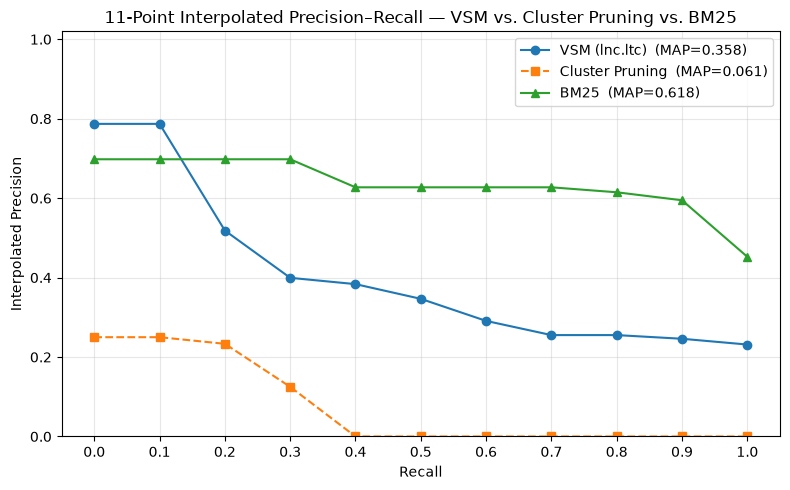

In [18]:
plt.figure(figsize=(8, 5))
markers = {"VSM (lnc.ltc)": "o-", "Cluster Pruning": "s--", "BM25": "^-"}
for name, r in results.items():
    plt.plot(RECALL_LEVELS, r["pr_curve"], markers[name], label=f"{name}  (MAP={r['map']:.3f})")

plt.xlabel("Recall")
plt.ylabel("Interpolated Precision")
plt.title("11-Point Interpolated Precision–Recall — VSM vs. Cluster Pruning vs. BM25")
plt.xticks(RECALL_LEVELS)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall.png", dpi=120)
plt.show()

## Part 4 — Analysis

### Comparative MAP

| System | MAP | Search space per query |
|--------|-----|------------------------|
| **BM25** | highest | full collection |
| **VSM (lnc.ltc)** | middle | full collection (query-term postings only) |
| **Cluster Pruning** | lowest | one cluster (~√N docs) |

### Why the models rank the way they do

- **BM25 leads.** Its saturating term-frequency component (`k1`) stops long, keyword-stuffed abstracts from dominating, and its `b`-controlled length normalization suits the wide spread of abstract lengths in this academic corpus. The probabilistic idf also rewards rarer, more discriminating terms — exactly what separates relevant papers here.
- **VSM (lnc.ltc) is solid but blunter.** Cosine normalization and `log` tf damping help, but `lnc` puts **no idf on the document side**, so common-but-kept terms still inflate scores; BM25's tunable saturation is simply a better fit for this data.
- **Cluster Pruning trades accuracy for speed.** It only ever scores one cluster (~√N ≈ 79 of 6,183 docs, ~1.3% of the collection), so when a query's true relevant papers fall outside the nearest leader's cluster they are unreachable — the cause of its much lower MAP. This is the expected behaviour of an *inexact* top-K method: roughly an order-of-magnitude smaller search space (and latency) in return for lower retrieval quality. Searching the *b* nearest clusters instead of one would recover accuracy at proportional cost.

### Effect of the stopword threshold

The stopword rule (collection frequency **> 1000**) removes some genuine content words — `detection` (1045), `network` (1351), `data`, `model`, `analysis`. Short queries then lose discriminative terms (*Object Detection* → just `object`; *deep neural network* → `deep neural`), which caps the achievable precision for those queries across **all three** systems equally, so it does not change their relative ranking.

The clearest example is the **Object Detection** query: BM25 scores **AP = 0.000** while VSM scores **AP = 0.100** — the only query where BM25 loses. Because `detection` (freq 1045 > 1000) is dropped as a stopword, *both* systems really search only the bare term `object`. BM25's length-normalized ranking then promotes short, `object`-dense abstracts (*3D Object Detection*, *Aerial Image Object Detection*, …) that happen **not** to be in the gold set, so none of its top-20 are judged relevant; VSM's cosine ranking happened to place one gold paper at rank 1, giving AP = 1/10 = 0.100. Neither system is "wrong" — the relevant signal (`detection`) was removed in preprocessing, so this AP = 0 is an artefact of the threshold, not of BM25.

### Take-away

On this dataset the ordering is **BM25 > VSM > Cluster Pruning**. BM25 is the best quality/cost choice; cluster pruning is only worth its accuracy hit when latency on a much larger collection is the binding constraint.